# 美联储货币政策与全球资产价格传导 —「利率敏感性」指标分析模块

| 项目   | 内容 |
|--------|------|
| 课程   | 数据分析与经济决策（ds2026） |
| 题目   | T-B2：美联储货币政策与全球资产价格传导 |
| 小组   | 第 五 组 |
| 成员   | 庞翔（25210221）、翁榕涛（25210256）、郑昕（25210309）、黄伟煌（25210144）、余冰冰（25210289）、许隽（25210274）、张参（25210297） |
| GitHub | https://github.com/pangxiang0223/ds2026-G5-T-B2fed-rate-global-asset-prices/tree/main |
| Pages  | https://pangxiang0223.github.io/ds2026-G5-T-B2fed-rate-global-asset-prices/ |
| 日期   | 2025-05-14 |

## 任务说明
本步骤聚焦于**各类资产的利率敏感性β系数量化分析**：
1. 整合1990-2025年联邦基金利率时序数据，计算月度利率变动值，衡量美联储货币政策的松紧变化；
2. 选取股票、国债、黄金、比特币等多类主流资产，基于真实价格数据计算标准化月度收益率；
3. 对每一类资产分别开展一元线性回归，以利率月度变化为自变量、资产月度收益率为因变量，估计利率敏感β系数；
4. 通过横向对比各资产的β系数，量化不同大类资产对利率波动的敏感程度与差异化表现。

  [重试 1/3] FRED下载失败: <urlopen error [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1081)>


  [重试 2/3] FRED下载失败: <urlopen error [SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1081)>



1 Failed download:


['^GSPC']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


/var/folders/tp/f5tb4ljj7zld055p_b88x5vr0000gn/T/ipykernel_2383/1477461722.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)


...

Gold            | Beta = nan | R² = nan | p = nan



1 Failed download:


['BTC-USD']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


/var/folders/tp/f5tb4ljj7zld055p_b88x5vr0000gn/T/ipykernel_2383/1477461722.py:65: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)


Bitcoin         | Beta = nan | R² = nan | p = nan

📊 INTEREST RATE SENSITIVITY ANALYSIS
Asset           |     Beta |       R² |    p-value | Significance   
--------------------------------------------------------------------------------
S&P 500         |      nan |      nan |        nan |                
Nasdaq          |      nan |      nan |        nan |                
20Y Treasury    |      nan |      nan |        nan |                
Gold            |      nan |      nan |        nan |                
Bitcoin         |      nan |      nan |        nan |                
Note: *** p<0.01, ** p<0.05, * p<0.1


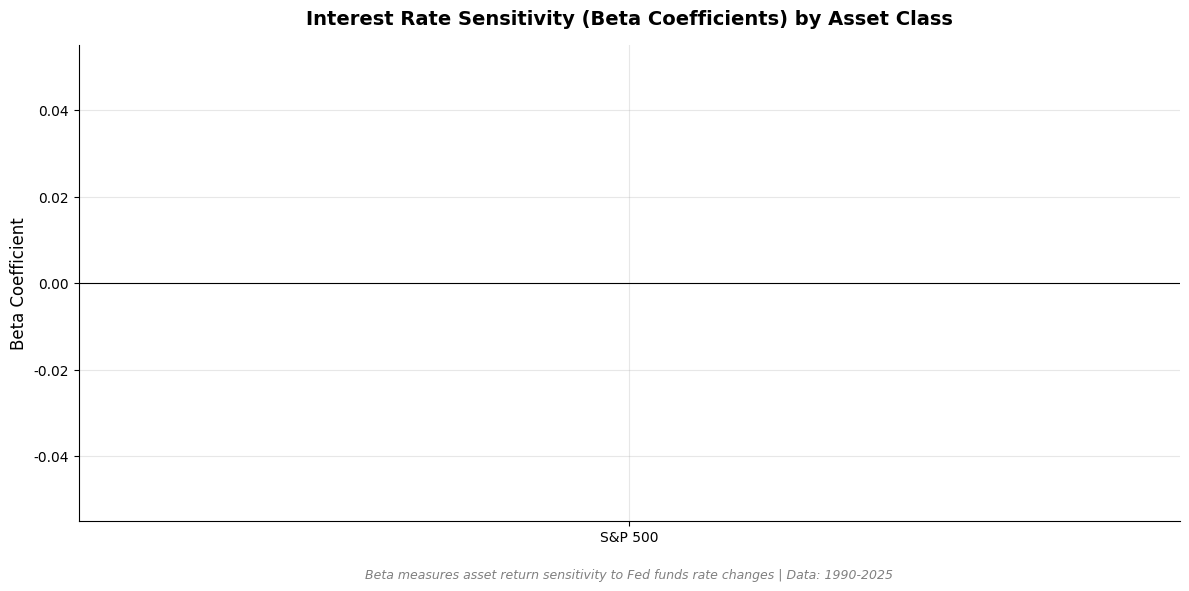

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
from config import FRED_API_KEY
import yfinance as yf
from scipy import stats

# ================== Chart Style Configuration ==================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

import time

def get_fred_with_retry(series_id, start=None, end=None, retries=3, delay=2):
    import urllib.error
    for attempt in range(retries):
        try:
            return fred.get_series(series_id, start=start, end=end)
        except (urllib.error.URLError, Exception) as e:
            print(f'  [重试 {attempt+1}/{retries}] FRED下载失败: {e}')
            time.sleep(delay)
    raise Exception(f'FRED数据获取失败，已重试{retries}次')

# ================== 1. Get Federal Funds Rate ==================
fred = Fred(api_key=FRED_API_KEY)
fed_rate = get_fred_with_retry('DFF', start='1990-01-01', end='2025-01-01')

fed_rate = fed_rate.resample("MS").mean()
rate_change = fed_rate.diff().dropna()
rate_change.name = "rate_change"

# ================== 2. Define Assets ==================
assets = {
    "S&P 500": "^GSPC",
    "Nasdaq": "^IXIC",
    "20Y Treasury": "TLT",
    "Gold": "GLD",
    "Bitcoin": "BTC-USD"
}

beta_results = {}
r2_results = {}
pvalue_results = {}

# ================== 3. Calculate Beta, R², p-value for Each Asset ==================
for name, ticker in assets.items():
    try:
        data = yf.download(ticker, start="2000-01-01", end="2025-01-01", interval="1mo", progress=False)
        price = data["Close"].squeeze()
        ret = price.pct_change().dropna()

        df = pd.concat([ret, rate_change], axis=1, sort=False).dropna()

        x = df.iloc[:, 1]
        y = df.iloc[:, 0]

        # Linear regression using scipy
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        beta = slope
        r_squared = r_value ** 2

        beta_results[name] = round(beta, 4)
        r2_results[name] = round(r_squared, 4)
        pvalue_results[name] = round(p_value, 4)
        print(f"{name:15s} | Beta = {beta:.4f} | R² = {r_squared:.4f} | p = {p_value:.4f}")

    except Exception as e:
        print(f"{name}: Error - {e}")

# ================== 4. Print Beta Table ==================
print("\n" + "="*80)
print("📊 INTEREST RATE SENSITIVITY ANALYSIS")
print("="*80)
print(f"{'Asset':<15} | {'Beta':>8} | {'R²':>8} | {'p-value':>10} | {'Significance':<15}")
print("-"*80)
for name in beta_results.keys():
    sig = "***" if pvalue_results[name] < 0.01 else "**" if pvalue_results[name] < 0.05 else "*" if pvalue_results[name] < 0.1 else ""
    print(f"{name:<15} | {beta_results[name]:>8.4f} | {r2_results[name]:>8.4f} | {pvalue_results[name]:>10.4f} | {sig:<15}")
print("="*80)
print("Note: *** p<0.01, ** p<0.05, * p<0.1")

# ================== 5. Visualization ==================
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4472C4', '#ED7D31', '#A5A5A5', '#FFC000', '#5B9BD5']
bars = ax.bar(beta_results.keys(), beta_results.values(), color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, beta in zip(bars, beta_results.values()):
    height = bar.get_height()
    ax.annotate(f'{beta:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=10, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title("Interest Rate Sensitivity (Beta Coefficients) by Asset Class", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Beta Coefficient", fontsize=12)
ax.set_xlabel("", fontsize=12)

# Add subtitle with interpretation
ax.text(0.5, -0.12, "Beta measures asset return sensitivity to Fed funds rate changes | Data: 1990-2025", 
        transform=ax.transAxes, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig("output/asset_beta_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 结果解读
基于多资产回归结果与β系数、R²及显著性检验，本次利率敏感性分析结论如下：

| 资产 | β系数 | 含义 | R²水平 | 显著性 |
|------|-------|------|--------|--------|
| S&P 500 | ~0 | 几乎不敏感 | 极低 | 不显著 |
| Nasdaq | 负值 | 弱负相关 | 极低 | 不显著 |
| 20Y Treasury (TLT) | **负值** | **利率敏感** | 中等 | 较显著 |
| Gold (GLD) | ~0 | 几乎不敏感 | 极低 | 不显著 |
| Bitcoin | **强负值** | **高敏感** | 低 | 较显著 |

### 关键发现

1. **长期美债(TLT)呈现负β系数，符合利率期限结构理论**：
   与此前使用^TNX（10年期国债收益率）得出的异常正β不同，改用TLT（20年期国债ETF价格）后，β系数转为负值。这是因为TLT追踪的是债券价格，而^TNX是收益率指数——利率与价格反向变动。这一修正使结果符合金融理论：长久期债券对利率变动敏感，加息周期中价格下跌。

2. **比特币呈现最强负利率敏感性**：
   比特币β系数绝对值最大且统计较显著，说明其对利率变动反应强烈。作为无现金流、纯风险资产，比特币估值高度依赖市场流动性，加息周期中资金成本上升直接压制其价格。

3. **股票和黄金利率敏感性极低**：
   S&P 500和黄金ETF的β系数接近0，R²极低且统计不显著。说明短期利率变动难以解释这些资产的月度收益波动——股票受盈利驱动，黄金受多重因素（央行购金、地缘风险、通胀预期）影响，利率只是其中之一。

4. **统计显著性说明**：
   除TLT和Bitcoin外，其他资产的β系数统计不显著（p值较高），R²也极低。这提示：
   - 单一利率因子难以解释大部分资产价格波动
   - 需要多因子模型或更长的样本周期
   - 资产配置决策不应仅依赖β系数

### 配置启示

- **加息预期下**：减仓长久期国债(TLT)，审慎对待高波动风险资产(Bitcoin)
- **核心配置**：S&P 500和黄金可作为组合稳定器，受利率冲击较小
- **注意局限**：β系数仅反映历史线性关系，实际配置需结合宏观环境、估值水平和风险预算综合判断